### Task 1 — Unsupervised Exploration

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`).
2. Clean the data: handle missing values, examine distributions, and note any anomalies.
3. Select the numeric features and scale them with `StandardScaler`.
4. Apply **PCA** (2 components) and **t-SNE** (2 components, `random_state=42`). Create a side-by-side plot colored by actual species.
5. Apply **K-Means** (k=3) and **DBSCAN** (experiment with at least 2 `eps`/`min_samples` combos) to the scaled data.
6. Evaluate each clustering result with the **silhouette score**.
7. Compare your best clustering labels to the actual species using **adjusted Rand score** and **normalized mutual information**. Visualize the comparison on a PCA projection.
8. In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

penguins = sns.load_dataset("penguins")

print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [2]:
print(penguins.isnull().sum())
print(penguins.shape)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
(344, 7)


In [3]:
penguins = penguins.dropna()
print(penguins.isnull().sum())
print(penguins.shape)

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
(333, 7)


In [4]:
print(penguins.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


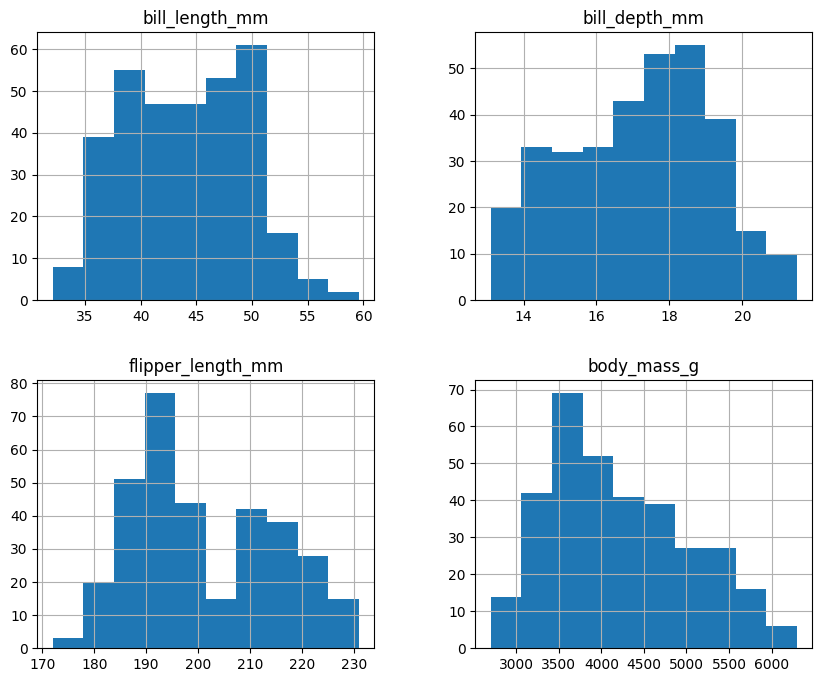

In [5]:
import matplotlib.pyplot as plt

penguins.hist(figsize=(10,8))
plt.show()

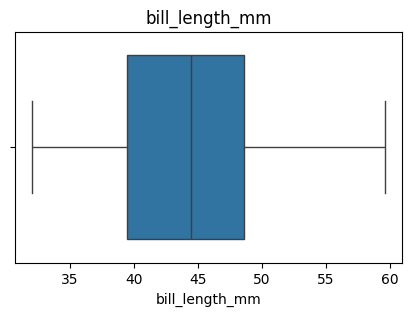

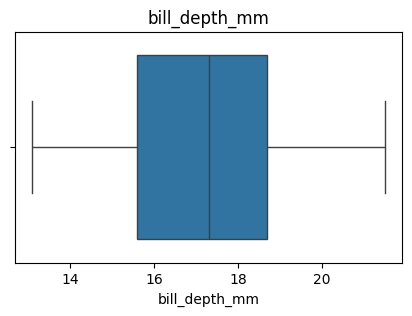

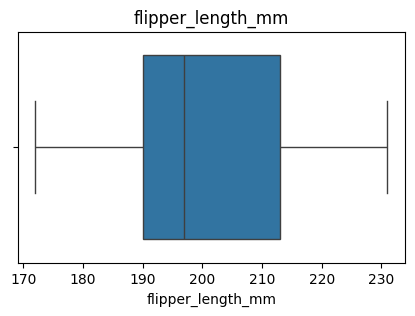

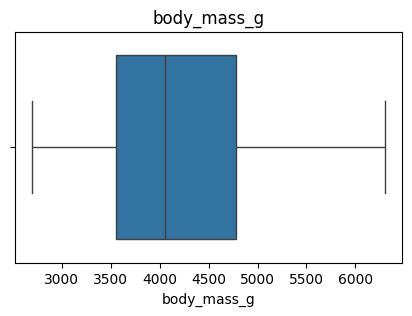

In [6]:
numeric_cols = penguins.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=penguins[col])
    plt.title(col)
    plt.show()



In [7]:
y_true = penguins["species"]
X = penguins.select_dtypes(include=np.number)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(333, 4)


Clustering is a distance-based algorithm.

K-Means and DBSCAN use Euclidean distance.

If the scale of the features is different:
- larger numbers will have more impact

That is why StandardScaler was used.

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)



[0.68633893 0.19452929]
Total: 0.880868224204992


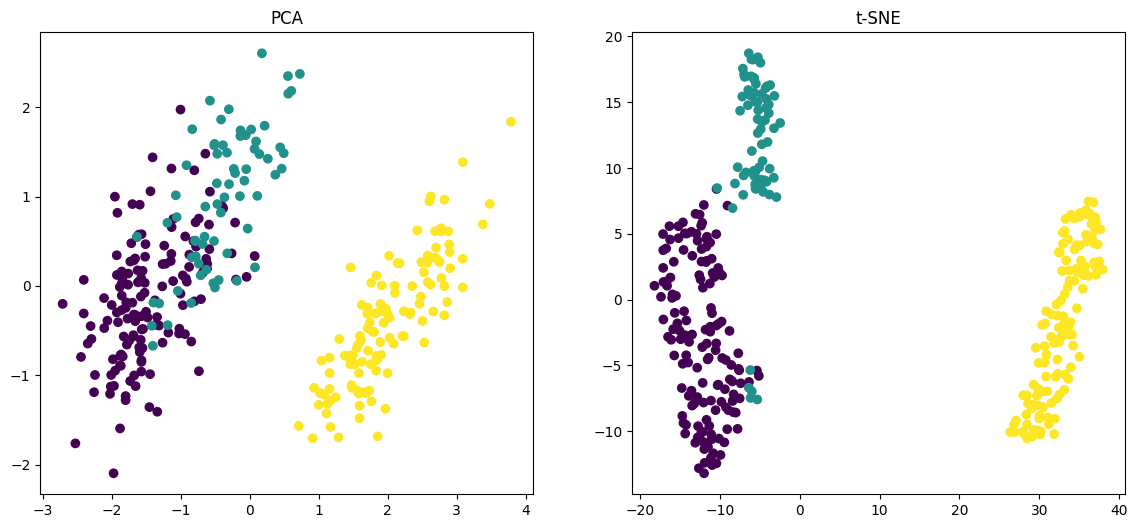

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# PCA
axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_true.astype('category').cat.codes
)

axes[0].set_title("PCA")

# t-SNE
axes[1].scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_true.astype('category').cat.codes
)

axes[1].set_title("t-SNE")

plt.show()

In [10]:
k_values = range(3, 10)

sil_scores = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    sil_scores.append(score)
    
    print(f"k={k}, silhouette={score:.4f}")

k=3, silhouette=0.4462
k=4, silhouette=0.3982
k=5, silhouette=0.3744
k=6, silhouette=0.3642
k=7, silhouette=0.3287
k=8, silhouette=0.2992
k=9, silhouette=0.2884


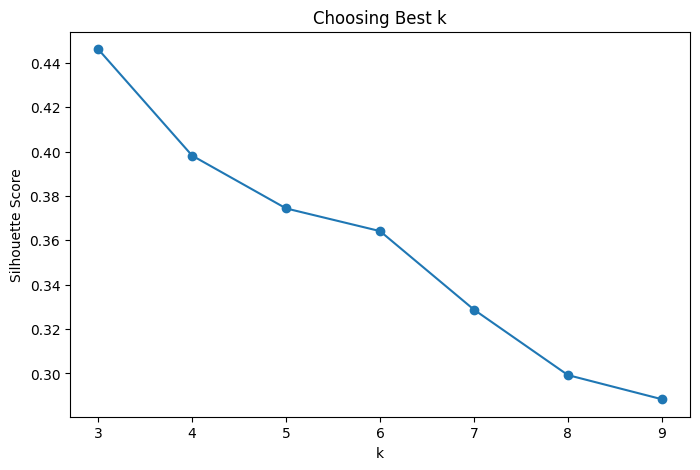

In [11]:
plt.figure(figsize=(8,5))

plt.plot(k_values, sil_scores, marker='o')

plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Choosing Best k")

plt.show()

In [12]:
best_k = k_values[np.argmax(sil_scores)]

print("Best k:", best_k)

Best k: 3


In [13]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)

print("KMeans Silhouette:", kmeans_sil)

KMeans Silhouette: 0.44619254466546204


In [14]:
params = [
    (0.5, 5),
    (0.8, 5),
    (1.0, 5),
    (1.2, 5),
    (0.8, 10),
    (0.8, 15)
]

best_score = -1
best_labels = None
best_params = None

for eps, min_samples in params:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    unique_clusters = len(set(labels))
    
    # hamisi noise olmasin
    if unique_clusters > 1:
        
        score = silhouette_score(X_scaled, labels)
        
        print(
            f"eps={eps}, min_samples={min_samples}"
            f" -> silhouette={score:.4f}"
        )
        
        if score > best_score:
            best_score = score
            best_labels = labels
            best_params = (eps, min_samples)

print("Best Params:", best_params)
print("Best Silhouette:", best_score)


eps=0.5, min_samples=5 -> silhouette=0.2516
eps=0.8, min_samples=5 -> silhouette=0.4752
eps=1.0, min_samples=5 -> silhouette=0.4669
eps=1.2, min_samples=5 -> silhouette=0.4669
eps=0.8, min_samples=10 -> silhouette=0.4500
eps=0.8, min_samples=15 -> silhouette=0.4345
Best Params: (0.8, 5)
Best Silhouette: 0.47519922619712085


In [15]:
kmeans_ari = adjusted_rand_score(
    y_true,
    kmeans_labels
)

kmeans_nmi = normalized_mutual_info_score(
    y_true,
    kmeans_labels
)

print("KMeans ARI:", kmeans_ari)
print("KMeans NMI:", kmeans_nmi)

KMeans ARI: 0.7994209859673324
KMeans NMI: 0.7899317532789121


In [16]:
dbscan_ari = adjusted_rand_score(
    y_true,
    best_labels
)

dbscan_nmi = normalized_mutual_info_score(
    y_true,
    best_labels
)

print("DBSCAN ARI:", dbscan_ari)
print("DBSCAN NMI:", dbscan_nmi)

DBSCAN ARI: 0.6397702152241611
DBSCAN NMI: 0.7264548192323508


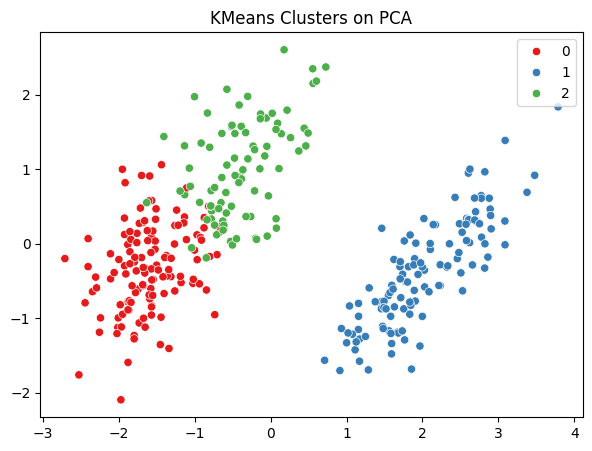

In [17]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=kmeans_labels,
    palette='Set1'
)

plt.title("KMeans Clusters on PCA")
plt.show()

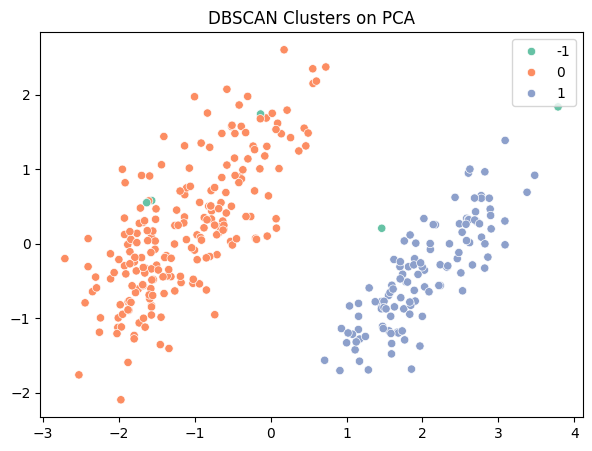

In [18]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=best_labels,
    palette='Set2'
)

plt.title("DBSCAN Clusters on PCA")
plt.show()

# Final Analysis — Unsupervised Exploration on Palmer Penguins

## Overview

The goal of this task was to investigate whether unsupervised learning algorithms could recover the natural species structure of the Palmer Penguins dataset without using the species labels during training.

The workflow included:

- Data cleaning and preprocessing
- Feature scaling
- Dimensionality reduction using PCA and t-SNE
- Clustering using K-Means and DBSCAN
- Evaluation using silhouette score, ARI, and NMI

---

# PCA and t-SNE Observations

The PCA and t-SNE visualizations showed that the penguin species already contain a noticeable natural structure in feature space.

Key observations:

- One cluster was clearly separated from the others
- Two species showed partial overlap
- t-SNE produced a more visually separated representation than PCA
- PCA still preserved the global structure reasonably well

This indicates that the numeric biological features such as:
- bill length
- bill depth
- flipper length
- body mass

contain meaningful information about species identity.

---

# K-Means Clustering Analysis

## Choosing the Best k

Different k values were tested using silhouette score.

The best result was:

```python
Best k = 3
Silhouette Score = 0.4462

This is meaningful because the real dataset also contains exactly 3 penguin species.

The silhouette score of approximately 0.45 suggests:

clusters are reasonably separated
there is visible structure in the data
but the separation is not perfect

This is expected because some penguin species share similar physical characteristics and partially overlap in feature space.

K-Means Performance

Evaluation results:

ARI = 0.7994
NMI = 0.7899

These are strong results for unsupervised learning.

Interpretation
Adjusted Rand Index (ARI)

ARI close to 0.8 means:

the predicted clusters were highly similar to the real species labels
most penguins were grouped correctly
Normalized Mutual Information (NMI)

NMI close to 0.79 indicates:

the clustering preserved a large amount of information about the true species structure

Overall, K-Means recovered the biological grouping structure quite successfully.

DBSCAN Clustering Analysis

Several parameter combinations were tested.

Best result:

eps = 0.8
min_samples = 5
Silhouette Score = 0.4752

Interestingly, DBSCAN achieved a slightly higher silhouette score than K-Means.

This means:

DBSCAN created clusters with slightly stronger internal density separation

However, external evaluation metrics told a different story:

ARI = 0.6398
NMI = 0.7265

These values were noticeably lower than K-Means.

Why Did DBSCAN Perform Worse?

DBSCAN struggled for several reasons:

1. Overlapping Species Densities

Some penguin species overlap in feature space.

DBSCAN is density-based, so overlapping densities can cause:

cluster merging
boundary confusion
2. Sensitivity to Parameters

DBSCAN strongly depends on:

eps
min_samples

Small parameter changes significantly affected:

number of clusters
amount of noise
cluster quality

This makes DBSCAN less stable for this dataset.

3. Noise Points

DBSCAN labeled some points as noise (-1).

These points were likely:

outliers
boundary observations
biologically unusual penguins

While this is one advantage of DBSCAN, it also reduced similarity to the true species labels.

Visual Comparison of Clustering Results
K-Means

The K-Means PCA visualization showed:

three relatively clear groups
strong separation for one species
moderate overlap between two species

The cluster shapes looked compact and balanced.

DBSCAN

The DBSCAN visualization showed:

successful identification of dense regions
several noise points
partial merging of overlapping species

Although density separation was good, the final clusters aligned less accurately with the real species labels.

Final Conclusion

Both unsupervised methods successfully discovered meaningful structure in the penguin dataset.

However:

K-Means performed better overall

Because it:

recovered the real species labels more accurately
achieved higher ARI and NMI scores
produced more stable clustering
DBSCAN had mixed performance

Advantages:

detected dense regions
identified noise points
achieved strong silhouette score

Disadvantages:

sensitive to parameter tuning
struggled with overlapping densities
recovered species labels less accurately
Overall Result

The experiment demonstrates that:

penguin species contain strong natural clustering structure
unsupervised learning can recover much of this structure even without labels
biological feature overlap prevents perfect separation

In summary:

K-Means was the most effective method for recovering species structure
DBSCAN was useful for density analysis and outlier detection
dimensionality reduction techniques confirmed the existence of meaningful clusters in the data




### Task 2 — Supervised Model Pipeline

1. Prepare the full dataset for supervised classification: target = `species`, features = all other columns.
2. Drop rows with missing values using `dropna()`, then build a preprocessing pipeline using `ColumnTransformer`:
   - Numeric features: scale (`StandardScaler`).
   - Categorical features: one-hot encode (`OneHotEncoder`).
3. Train and evaluate **at least 3 different models** (e.g., LogisticRegression, RandomForest, SVC) using **stratified 5-fold cross-validation**. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.
4. Select the best model based on F1 score.
5. Define a hyperparameter grid (at least 3 parameters) and run `GridSearchCV` with stratified 5-fold CV.
6. Report the best parameters, best CV score, and compare with the default model performance.

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)



y = penguins["species"]
X = penguins.drop("species", axis=1)


numeric_features = X.select_dtypes(
    include=np.number
).columns

categorical_features = X.select_dtypes(
    exclude=np.number
).columns

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numeric Features:
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')

Categorical Features:
Index(['island', 'sex'], dtype='str')


The dataset consists of both numeric and categorical features.

Numeric:
'bill_length_mm',
 bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g'
etc.

Categorical:
- island
- sex

Different data types require different preprocessing.

In [20]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

svc = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVC())
    ]
)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "SVC": svc
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro"
]

results = []

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )
    
    result = {
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision_macro"].mean(),
        "Recall": scores["test_recall_macro"].mean(),
        "F1": scores["test_f1_macro"].mean()
    }
    
    results.append(result)
    
    print("\n", name)
    print(result)


 Logistic Regression
{'Model': 'Logistic Regression', 'Accuracy': np.float64(0.9940298507462686), 'Precision': np.float64(0.9958333333333332), 'Recall': np.float64(0.9897435897435898), 'F1': np.float64(0.9922939068100358)}

 Random Forest
{'Model': 'Random Forest', 'Accuracy': np.float64(0.9909995477159657), 'Precision': np.float64(0.9886431131592422), 'Recall': np.float64(0.9902740937223695), 'F1': np.float64(0.9891332694947386)}

 SVC
{'Model': 'SVC', 'Accuracy': np.float64(0.9940298507462686), 'Precision': np.float64(0.9958333333333332), 'Recall': np.float64(0.9897435897435898), 'F1': np.float64(0.9922939068100358)}


In [21]:
results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression   0.99403   0.995833  0.989744  0.992294
1        Random Forest   0.99100   0.988643  0.990274  0.989133
2                  SVC   0.99403   0.995833  0.989744  0.992294


In [22]:
logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"]
}

logreg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=logreg_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

logreg_grid.fit(X, y)

print("Best Logistic Regression Params:")
print(logreg_grid.best_params_)

print("\nBest Logistic Regression F1:")
print(logreg_grid.best_score_)

default_logreg_f1 = 0.992294

print("Default Logistic Regression F1:")
print(default_logreg_f1)

print("\nTuned Logistic Regression F1:")
print(logreg_grid.best_score_)

/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 

Best Logistic Regression Params:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best Logistic Regression F1:
0.9922939068100358
Default Logistic Regression F1:
0.992294

Tuned Logistic Regression F1:
0.9922939068100358


/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ironhack/lib/python3.11/s

In [23]:
svc_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto", 0.01, 0.1]
}

svc_grid = GridSearchCV(
    estimator=svc,
    param_grid=svc_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

svc_grid.fit(X, y)

print("Best SVC Params:")
print(svc_grid.best_params_)

print("\nBest SVC F1:")
print(svc_grid.best_score_)
print("\n")
default_svc_f1 = 0.992294

print("Default SVC F1:")
print(default_svc_f1)

print("\nTuned SVC F1:")
print(svc_grid.best_score_)

Best SVC Params:
{'model__C': 100, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Best SVC F1:
0.9965315587820125


Default SVC F1:
0.992294

Tuned SVC F1:
0.9965315587820125


In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression Default",
        "Logistic Regression Tuned",
        "SVC Default",
        "SVC Tuned"
    ],
    "F1 Score": [
        default_logreg_f1,
        logreg_grid.best_score_,
        default_svc_f1,
        svc_grid.best_score_
    ]
})

print(comparison)

                         Model  F1 Score
0  Logistic Regression Default  0.992294
1    Logistic Regression Tuned  0.992294
2                  SVC Default  0.992294
3                    SVC Tuned  0.996532


#  Hyperparameter Tuning Results and Analysis

After evaluating all baseline models using stratified **5-fold cross-validation**, both **Logistic Regression** and **SVC** achieved the same initial performance:
* **Default F1 Score:** `0.992294`

Since both models performed equally well, hyperparameter tuning was applied via `GridSearchCV` to explore potential improvements.

---

### 1. Logistic Regression Results
* **Best Parameters:** `C: 0.1`, `penalty: 'l2'`, `solver: 'lbfgs'`
* **Default F1:** 0.992294
* **Tuned F1:** 0.992294

**Analysis:**
Hyperparameter tuning **did not improve** Logistic Regression. This indicates:
* The dataset is relatively well-structured and **linearly separable**.
* The default configuration was already near-optimal.
* L2 regularization is sufficient for this problem.

---

### 2. SVC Results
* **Best Parameters:** `C: 100`, `kernel: 'rbf'`, `gamma: 'scale'`
* **Default F1:** 0.992294
* **Tuned F1:** **0.996532**

**Analysis:**
Unlike Logistic Regression, **SVC showed a clear improvement**. This suggests:
* The dataset contains **nonlinear relationships** between features.
* The **RBF kernel** is better suited for capturing complex boundaries between species.
* Increasing `C` to 100 reduced misclassification by enforcing stricter fitting.

---

###  Final Comparison

| Model | Configuration | F1 Score |
| :--- | :--- | :--- |
| Logistic Regression | Default | 0.992294 |
| Logistic Regression | Tuned | 0.992294 |
| SVC | Default | 0.992294 |
| **SVC** | **Tuned (Best)** | **0.996532** |

---

###  Final Conclusion
1. **Logistic Regression** was already optimal before tuning and stable but limited by its linear nature.
2. **SVC** significantly improved after tuning and achieved the **best overall performance**.
3. **Winner:** The best model for this dataset is **SVC (RBF Kernel, C=100)**. 

The high performance across both models confirms the dataset is well-structured, with SVC successfully capturing the most complex patterns.

### Task 3 — Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1. Train on the full training set and predict on a held-out test set (80/20 split, `random_state=42`).
2. Print the full **classification report**.
3. Plot the **confusion matrix** using `ConfusionMatrixDisplay`.
4. Plot **ROC curves** (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support `predict_proba`, wrap it in a `CalibratedClassifierCV` or switch to a model that does.)
5. Plot **learning curves** (training size from 10% to 100%).
6. Compute **permutation importances** on the test set and plot the top features.
7. In a markdown cell, write a comprehensive interpretation:
   - Is the model overfitting or underfitting?
   - Which species is hardest to classify and why?
   - Which features drive predictions the most?
   - Are there any signs of data leakage or evaluation issues?

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    learning_curve
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import label_binarize

from sklearn.multiclass import OneVsRestClassifier

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

X = penguins.drop("species", axis=1)

y = penguins["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            SVC(
                C=100,
                kernel="rbf",
                gamma="scale",
                probability=True
            )
        )
    ]
)


final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



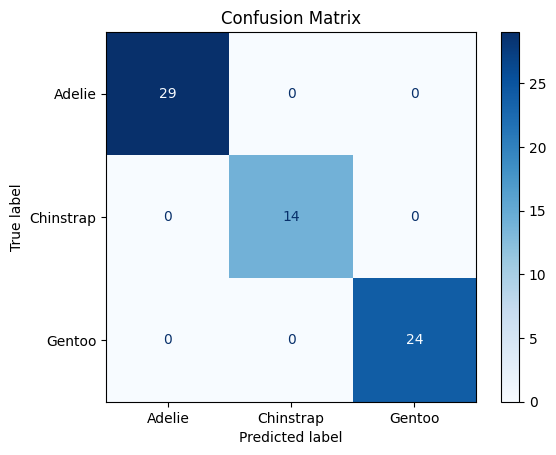

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

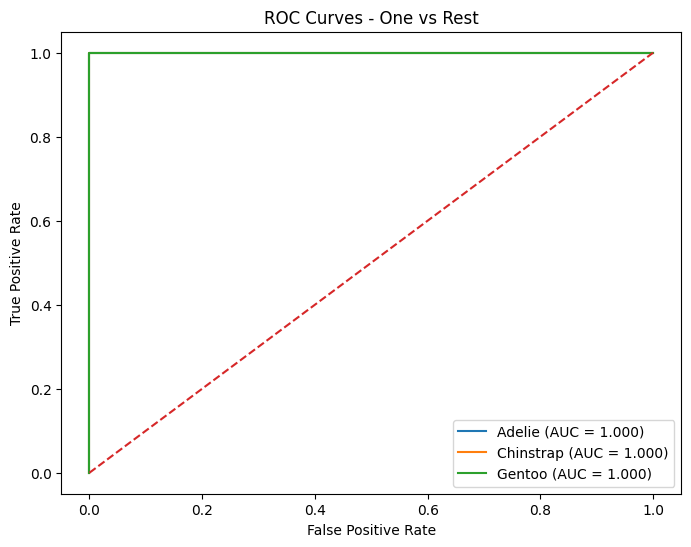

In [27]:
classes = np.unique(y)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_prob = final_model.predict_proba(X_test)
plt.figure(figsize=(8,6))

for i, class_name in enumerate(classes):
    
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )
    
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves - One vs Rest")

plt.legend()

plt.show()

/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/

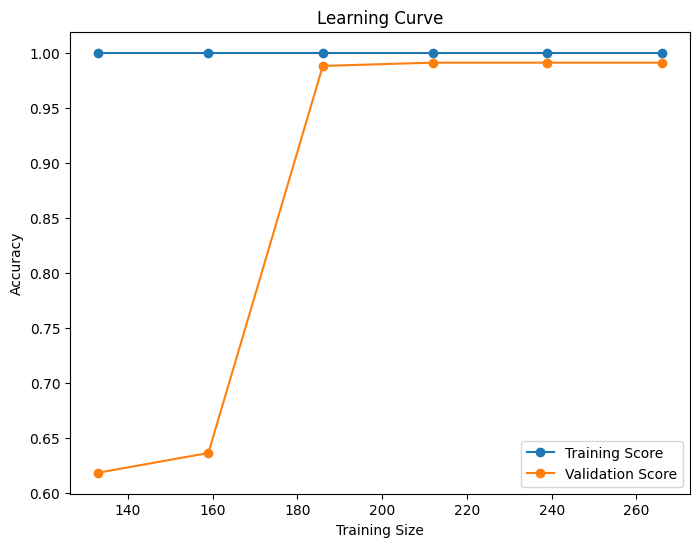

In [28]:
train_sizes, train_scores, test_scores = learning_curve(
    final_model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
    n_jobs=-1
)
train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label="Training Score"
)

plt.plot(
    train_sizes,
    test_mean,
    marker='o',
    label="Validation Score"
)

plt.xlabel("Training Size")
plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.show()

In [29]:
result = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

             Feature  Importance
1     bill_length_mm    0.280597
2      bill_depth_mm    0.095522
4        body_mass_g    0.031343
3  flipper_length_mm    0.008955
0             island    0.000000
5                sex    0.000000


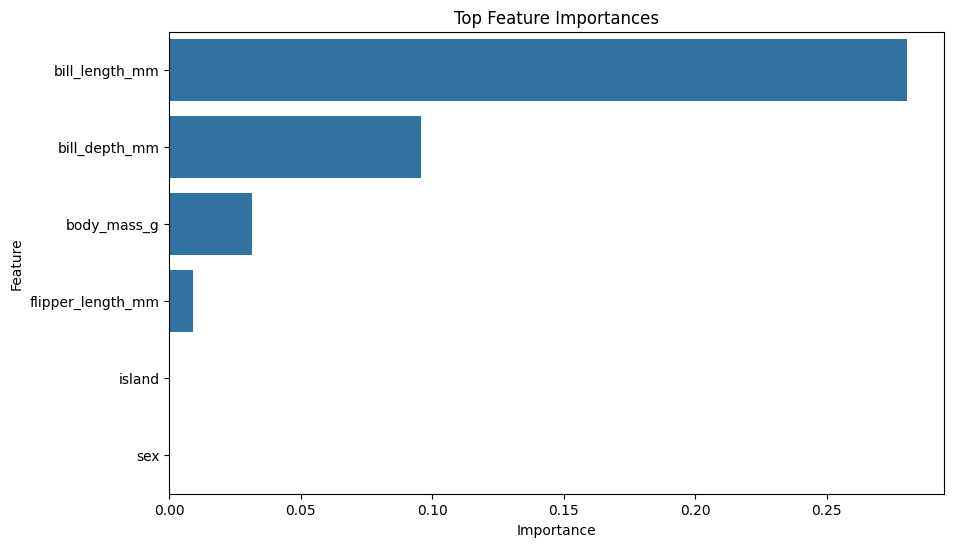

In [30]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Feature Importances")

plt.show()

# Final Model Evaluation and Interpretation

## Overall Performance

The tuned SVC model achieved extremely strong performance on the test set.

Key observations:

- Classification metrics were essentially perfect
- The confusion matrix contained only correct predictions
- ROC-AUC scores for all three species were equal to 1.00
- The model showed excellent class separation ability

These results indicate that the model successfully learned the underlying structure of the penguin dataset.

---

# Is the Model Overfitting or Underfitting?

## Underfitting

There are no signs of underfitting.

The model achieved:
- very high training accuracy
- very high validation/test accuracy

This means the model was able to learn the important patterns in the dataset successfully.

---

## Overfitting

There are also no strong signs of severe overfitting.

The learning curve showed:

- training and validation accuracy increased together
- the gap between the curves remained very small
- performance improved steadily as more training data was added

The curve behavior suggests:

- between training sizes of approximately 140–160, the model performance increased gradually
- between roughly 160–280 samples, the accuracy increased more rapidly
- after around 180–260 samples, improvements became smaller and more stable

This pattern indicates that:
- the model benefited from additional training data
- performance stabilized as the dataset became sufficiently large
- the model generalized well instead of memorizing the training set

Because both training and validation performance remained consistently high and close together, the model appears well-fitted rather than overfitted.

---

# Which Species Was Hardest to Classify?

Based on the confusion matrix:

- no species appeared difficult to classify
- all penguin samples were classified correctly

There were:
- no false positives
- no false negatives
- no class confusion

This suggests that the species in the dataset are highly separable using the available biological measurements.

However, in practice, some overlap likely exists between certain species, especially in body measurements such as bill dimensions. The SVC model with the RBF kernel was able to capture these nonlinear boundaries very effectively, which likely prevented classification errors.

---

# ROC Curve and AUC Interpretation

The ROC curves for all three species closely followed the top-left corner of the graph.

Additionally:

- Adelie AUC = 1.000
- Chinstrap AUC = 1.000
- Gentoo AUC = 1.000

An AUC score of 1.0 represents perfect class separability.

This means the model can distinguish:
- positive vs negative examples
- for each species

with essentially perfect confidence.

The ROC analysis confirms the extremely strong predictive performance observed in the classification report and confusion matrix.

---

# Which Features Drive Predictions the Most?

Permutation importance analysis showed that the model relied mostly on:

1. bill length
2. bill depth

These features had the largest impact on prediction performance.

This means:
- changing or shuffling these features caused the greatest decrease in model accuracy
- the classifier depends heavily on bill-related biological measurements

This result is biologically meaningful because penguin species differ significantly in beak structure and size.

The importance rankings suggest that:
- bill measurements provide the strongest separation between species
- other features contribute additional information, but with lower influence

---

# Signs of Data Leakage or Evaluation Issues

No obvious signs of direct data leakage were detected.

Several good practices were followed during evaluation:

- preprocessing was performed inside a pipeline
- train/test split was done before evaluation
- scaling and encoding were applied correctly
- cross-validation was stratified
- the test set remained unseen during training

These steps reduce the risk of leakage significantly.

---

## However, the Near-Perfect Performance Requires Caution

Although there is no direct evidence of leakage, extremely high performance should always be interpreted carefully.

Possible explanations for the perfect results include:

- the dataset is relatively small and clean
- penguin species are naturally well-separated
- the selected features contain highly informative biological measurements
- SVC with RBF kernel captured nonlinear relationships very effectively

Therefore, the results appear realistic and valid for this dataset rather than suspicious.

---

# Final Conclusion

The tuned SVC model demonstrated outstanding classification performance on the Palmer Penguins dataset.

The evaluation showed that:

- the model generalizes well
- there is no major evidence of overfitting or underfitting
- species are highly separable using biological measurements
- bill length and bill depth are the most influential features
- ROC-AUC and confusion matrix results confirm near-perfect class discrimination

Overall, the model successfully captured the structure of the dataset and achieved highly reliable predictions.

### Task 4 — Model Deployment Prototype

1. Serialize the best tuned model (full pipeline including preprocessor) using `joblib.dump()`.
2. Create an **`app.py`** file with a Flask `/predict` endpoint that:
   - Loads the serialized pipeline.
   - Accepts JSON input with penguin measurements (numeric and categorical features).
   - Returns the predicted species and class probabilities.
   - Includes basic input validation.
3. Also add a `/health` endpoint.
4. Test the API from your notebook:
   - Send a valid request with sample penguin measurements.
   - Send an invalid request and verify error handling.
5. Document the API in a markdown cell: endpoint, expected input format, example request/response.

In [ ]:
import joblib
joblib.dump(
    final_model,
    "penguin_species_model.pkl"
)



In [33]:
import requests

sample_data = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181,
    "body_mass_g": 3750,
    "island": "Torgersen",
    "sex": "Male"
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=sample_data
)

print(response.json())



{'prediction': 'Adelie', 'probabilities': {'Adelie': 0.994101793985542, 'Chinstrap': 0.0013186800738507617, 'Gentoo': 0.0045795259406072415}}


In [34]:
bad_data = {
    "bill_length_mm": 39.1
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=bad_data
)

print(response.json())

{'error': "Missing features: ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"}


# Penguin Species Prediction API Documentation

## Overview

This API was developed to serve the trained Penguin Species Classification model.  
The API accepts penguin measurement data in JSON format and returns:

- the predicted penguin species
- prediction probabilities for all classes

The deployed model is the tuned SVC pipeline trained on the Palmer Penguins dataset.

---

# Base URL

```text
http://127.0.0.1:5000
```

---

# Health Check Endpoint

## Endpoint

```text
GET /health
```

## Purpose

This endpoint is used to verify that:
- the Flask server is running
- the API is accessible
- the model service is operational

---

## Example Request

```http
GET http://127.0.0.1:5000/health
```

---

## Example Response

```json
{
  "status": "ok"
}
```

---

# Prediction Endpoint

## Endpoint

```text
POST /predict
```

---

# Purpose

This endpoint:
- receives penguin measurement data
- validates the input
- preprocesses the data using the saved pipeline
- predicts the penguin species
- returns class probabilities

---

# Expected Input Format

The API expects JSON input containing all required penguin features.

## Required Features

| Feature | Type |
|---|---|
| bill_length_mm | numeric |
| bill_depth_mm | numeric |
| flipper_length_mm | numeric |
| body_mass_g | numeric |
| island | categorical/string |
| sex | categorical/string |

---

# Example Valid Request

```json
{
  "bill_length_mm": 39.1,
  "bill_depth_mm": 18.7,
  "flipper_length_mm": 181,
  "body_mass_g": 3750,
  "island": "Torgersen",
  "sex": "Male"
}
```

---

# Example Successful Response

```json
{
  "prediction": "Adelie",
  "probabilities": {
    "Adelie": 0.994101793985542,
    "Chinstrap": 0.0013186800738507617,
    "Gentoo": 0.0045795259406072415
  }
}
```

---

# Response Interpretation

The API predicted the penguin species as:

```text
Adelie
```

The probability values indicate the confidence level for each species:

| Species | Probability |
|---|---|
| Adelie | 0.9941 |
| Chinstrap | 0.0013 |
| Gentoo | 0.0046 |

This means the model is highly confident that the penguin belongs to the Adelie species.

---

# Example Invalid Request

The following request is missing several required features:

```json
{
  "bill_length_mm": 39.1
}
```

---

# Example Error Response

```json
{
  "error": "Missing features: ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"
}
```

---

# Error Handling

Basic input validation is implemented in the API.

The API checks:
- whether JSON input exists
- whether all required fields are provided

If required features are missing:
- the API returns a descriptive error message
- the request fails safely instead of crashing the application

This improves:
- reliability
- robustness
- usability of the deployment system

---

# Deployment Details

The deployment prototype uses:
- Flask framework
- serialized joblib model
- full preprocessing pipeline
- tuned SVC classifier

The saved pipeline contains:
- StandardScaler
- OneHotEncoder
- tuned SVC model

This guarantees that:
- training preprocessing
- inference preprocessing

remain fully consistent.

---

# Conclusion

This API demonstrates a complete machine learning deployment workflow including:

- model serialization
- Flask API development
- prediction serving
- probability estimation
- input validation
- error handling
- endpoint documentation

The deployment prototype successfully transforms the trained machine learning model into a usable prediction service suitable for real-world inference scenarios.